In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Cargamos la base de ventas de piso

df = pd.read_csv(
    "ventas_piso_2024_sin_nulos (1).csv",
    dtype=str,
    keep_default_na=False
)

df.head()

,Asesor,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,dic,ene
0,ABIGAIL,,0,0,0,0,0,0,0,0,0,0,0
1,ALAN GONZALES,,0,0,0,0,0,0,0,0,1,2,4
2,ALICIA LEDESMA,,0,0,0,0,0,0,0,0,0,0,0
3,AURELIO FELIPE,,0,0,0,0,0,0,0,2,0,0,0
4,CARLOS ALBERTO NIETO,,0,0,0,0,0,0,2,0,3,1,0


In [6]:
#Quitamos espacios normales e invisibles
#de los nombres de las columnas

df.columns = (
    df.columns
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
)

#Quitamos espacios normales e invisibles
#de los nombres de los asesores

df["Asesor"] = (
    df["Asesor"]
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
    .str.upper()
)

df.head()

,Asesor,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,dic,ene
0,ABIGAIL,,0,0,0,0,0,0,0,0,0,0,0
1,ALAN GONZALES,,0,0,0,0,0,0,0,0,1,2,4
2,ALICIA LEDESMA,,0,0,0,0,0,0,0,0,0,0,0
3,AURELIO FELIPE,,0,0,0,0,0,0,0,2,0,0,0
4,CARLOS ALBERTO NIETO,,0,0,0,0,0,0,2,0,3,1,0


In [7]:
#Declaramos las columnas correspondientes a los meses

meses = [
    "feb", "mar", "abr", "may",
    "jun", "jul", "ago", "sep",
    "oct", "nov", "dic", "ene"
]

#Quitamos espacios invisibles, sustituimos vacíos por cero
#y convertimos todos los meses a números enteros

for columna in meses:
    df[columna] = (
        df[columna]
        .str.replace("\u00a0", "", regex=False)
        .str.strip()
        .replace("", "0")
    )

    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    ).fillna(0).astype(int)

df.head()

,Asesor,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,dic,ene
0,ABIGAIL,0,0,0,0,0,0,0,0,0,0,0,0
1,ALAN GONZALES,0,0,0,0,0,0,0,0,0,1,2,4
2,ALICIA LEDESMA,0,0,0,0,0,0,0,0,0,0,0,0
3,AURELIO FELIPE,0,0,0,0,0,0,0,0,2,0,0,0
4,CARLOS ALBERTO NIETO,0,0,0,0,0,0,0,2,0,3,1,0


In [8]:
#Definimos las cuentas administrativas
#que no representan asesores reales

cuentas_administrativas = [
    "SYS_COMPETITION",
    "USUARIO DE BDC Y CASA"
]

#Guardamos el número de filas antes de eliminarlas

filas_antes = len(df)

#Eliminamos únicamente las cuentas administrativas

df = df[
    ~df["Asesor"].isin(cuentas_administrativas)
].copy()

#Reiniciamos el índice

df = df.reset_index(drop=True)

print("Filas antes:", filas_antes)
print("Cuentas administrativas eliminadas:", filas_antes - len(df))
print("Asesores conservados:", len(df))

Filas antes: 40
Cuentas administrativas eliminadas: 2
Asesores conservados: 38


In [9]:
#Revisamos valores nulos, duplicados y tipos de datos

print("Tamaño final:", df.shape)
print("Valores nulos:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())

print("\nTipos de datos:")
print(df.dtypes)

Tamaño final: (38, 13)
Valores nulos: 0
Filas duplicadas: 0

Tipos de datos:
Asesor      str
feb       int64
mar       int64
abr       int64
may       int64
jun       int64
jul       int64
ago       int64
sep       int64
oct       int64
nov       int64
dic       int64
ene       int64
dtype: object


In [10]:
#Guardamos la base limpia en un archivo Excel

df.to_excel(
    "ventas_piso_2024_limpia.xlsx",
    index=False
)

print("La base limpia fue guardada correctamente")

La base limpia fue guardada correctamente


In [11]:
#Declaramos las columnas correspondientes a los meses

meses = [
    "feb", "mar", "abr", "may",
    "jun", "jul", "ago", "sep",
    "oct", "nov", "dic", "ene"
]

#Transformamos la base de formato ancho a formato largo

df_largo = df.melt(
    id_vars="Asesor",
    value_vars=meses,
    var_name="Mes",
    value_name="Ventas"
)

df_largo.head()

,Asesor,Mes,Ventas
0,ABIGAIL,feb,0
1,ALAN GONZALES,feb,0
2,ALICIA LEDESMA,feb,0
3,AURELIO FELIPE,feb,0
4,CARLOS ALBERTO NIETO,feb,0


In [12]:
#Asignamos el orden temporal de los meses

orden_meses = {
    "feb": 1,
    "mar": 2,
    "abr": 3,
    "may": 4,
    "jun": 5,
    "jul": 6,
    "ago": 7,
    "sep": 8,
    "oct": 9,
    "nov": 10,
    "dic": 11,
    "ene": 12
}

df_largo["Periodo"] = df_largo["Mes"].map(orden_meses)

#Ordenamos la base cronológicamente

df_largo = df_largo.sort_values(
    ["Periodo", "Asesor"]
).reset_index(drop=True)

df_largo.head()

,Asesor,Mes,Ventas,Periodo
0,ABIGAIL,feb,0,1
1,ALAN GONZALES,feb,0,1
2,ALICIA LEDESMA,feb,0,1
3,AURELIO FELIPE,feb,0,1
4,CARLOS ALBERTO NIETO,feb,0,1


In [13]:
#Comprobamos el tamaño y la calidad de la base transformada

print("Tamaño:", df_largo.shape)
print("Valores nulos:", df_largo.isnull().sum().sum())
print("Duplicados:", df_largo.duplicated().sum())
print("Ventas totales:", df_largo["Ventas"].sum())

Tamaño: (456, 4)
Valores nulos: 0
Duplicados: 0
Ventas totales: 84


In [14]:
#Sumamos las ventas de todos los asesores por periodo

ventas_mensuales = (
    df_largo
    .groupby(["Periodo", "Mes"], as_index=False)["Ventas"]
    .sum()
    .sort_values("Periodo")
)

ventas_mensuales

,Periodo,Mes,Ventas
0,1,feb,9
1,2,mar,5
2,3,abr,9
3,4,may,1
4,5,jun,3
5,6,jul,10
6,7,ago,9
7,8,sep,6
8,9,oct,3
9,10,nov,11


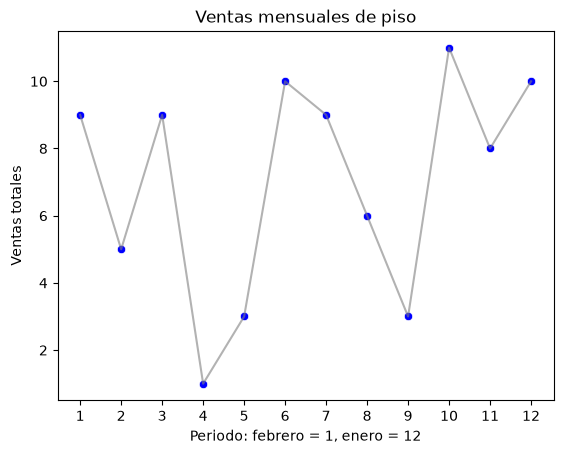

In [15]:
#Graficamos las ventas totales de cada mes

sns.scatterplot(
    x="Periodo",
    y="Ventas",
    color="blue",
    data=ventas_mensuales
)

plt.plot(
    ventas_mensuales["Periodo"],
    ventas_mensuales["Ventas"],
    color="gray",
    alpha=0.6
)

plt.title("Ventas mensuales de piso")
plt.xlabel("Periodo: febrero = 1, enero = 12")
plt.ylabel("Ventas totales")
plt.xticks(range(1, 13))
plt.show()

In [16]:
#Declaramos la variable independiente y dependiente

Vars_Indep = ventas_mensuales[["Periodo"]]

Var_Dep = ventas_mensuales["Ventas"]

In [17]:
#Importamos la función de regresión lineal

from sklearn.linear_model import LinearRegression

#Definimos el modelo

model = LinearRegression()

#Ajustamos el modelo con las variables declaradas

model.fit(
    X=Vars_Indep,
    y=Var_Dep
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.24]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Periodo']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.409
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [18]:
#Mostramos los coeficientes del modelo

print("Intercepto:", model.intercept_)
print("Pendiente:", model.coef_[0])

Intercepto: 5.409090909090909
Pendiente: 0.24475524475524474


In [19]:
#Mostramos la ecuación estimada

print(
    f"Ventas = {model.intercept_:.4f} "
    f"+ {model.coef_[0]:.4f}(Periodo)"
)

Ventas = 5.4091 + 0.2448(Periodo)


In [20]:
#Evaluamos la eficiencia del modelo mediante R cuadrada

coef_Deter = model.score(
    Vars_Indep,
    Var_Dep
)

print("R²:", coef_Deter)

R²: 0.07138694638694643


In [21]:
#Predecimos las ventas mensuales

y_pred = model.predict(
    X=ventas_mensuales[["Periodo"]]
)

#Agregamos las predicciones

ventas_mensuales["Predicciones"] = y_pred

ventas_mensuales

,Periodo,Mes,Ventas,Predicciones
0,1,feb,9,5.653846
1,2,mar,5,5.898601
2,3,abr,9,6.143357
3,4,may,1,6.388112
4,5,jun,3,6.632867
5,6,jul,10,6.877622
6,7,ago,9,7.122378
7,8,sep,6,7.367133
8,9,oct,3,7.611888
9,10,nov,11,7.856643


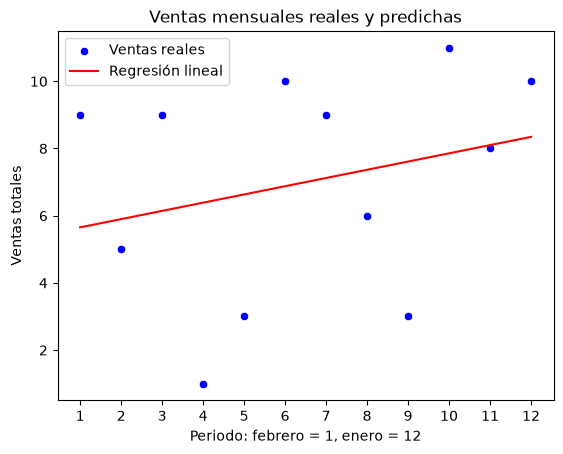

In [22]:
#Visualizamos las ventas reales y las ventas predichas

sns.scatterplot(
    x="Periodo",
    y="Ventas",
    color="blue",
    data=ventas_mensuales,
    label="Ventas reales"
)

sns.lineplot(
    x="Periodo",
    y="Predicciones",
    color="red",
    data=ventas_mensuales,
    label="Regresión lineal"
)

plt.title("Ventas mensuales reales y predichas")
plt.xlabel("Periodo: febrero = 1, enero = 12")
plt.ylabel("Ventas totales")
plt.xticks(range(1, 13))
plt.show()

In [23]:
#Calculamos el coeficiente de correlación
#entre el Periodo y las Ventas

coef_Correl = ventas_mensuales["Periodo"].corr(
    ventas_mensuales["Ventas"]
)

print("Coeficiente de correlación:", coef_Correl)

Coeficiente de correlación: 0.26718335724170095


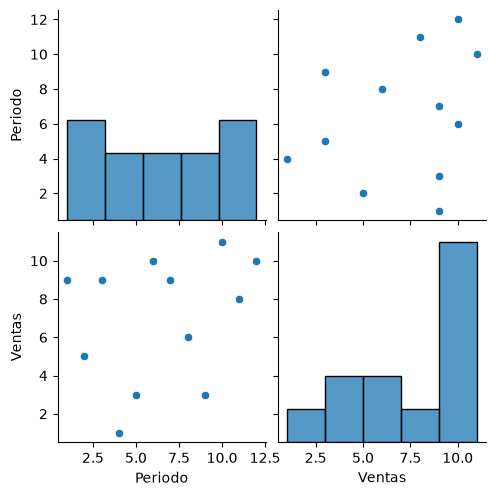

In [24]:
#Seleccionamos las variables originales del análisis

df_numerico = ventas_mensuales[
    ["Periodo", "Ventas"]
]

#Graficamos las dispersiones entre las variables

sns.pairplot(df_numerico)

plt.show()

In [25]:
#Encontramos las correlaciones entre las variables

Corr_Factors = df_numerico.corr()

Corr_Factors

,Periodo,Ventas
Periodo,1.000000,0.267183
Ventas,0.267183,1.000000


In [26]:
#Calculamos el valor absoluto de las correlaciones

Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

,Periodo,Ventas
Periodo,1.000000,0.267183
Ventas,0.267183,1.000000


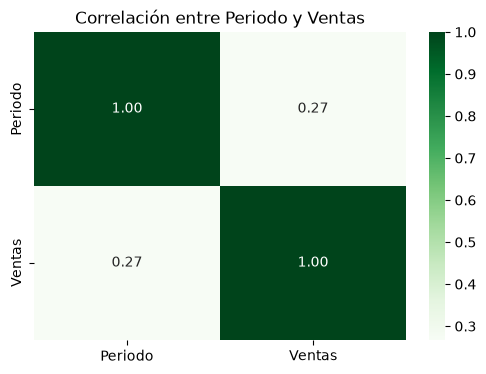

In [27]:
#Graficamos el mapa de calor
#con los valores de correlación

plt.figure(figsize=(6, 4))

Heat_Map = sns.heatmap(
    Corr_Factors1,
    cmap="Greens",
    annot=True,
    fmt=".2f"
)

plt.title("Correlación entre Periodo y Ventas")
plt.show()

In [28]:
#Guardamos la base mensual con las predicciones

ventas_mensuales.to_excel(
    "resultados_regresion_ventas_piso.xlsx",
    index=False
)

print("Los resultados fueron guardados correctamente")

Los resultados fueron guardados correctamente


In [29]:
#Cargamos la base de datos

archivo = "ventas_piso_2025_sin_nulos (1).csv"

df = pd.read_csv(
    archivo,
    encoding="utf-8-sig",
    dtype=str,
    keep_default_na=False
)

df.head()

,Asesor,feb,mar,abr,May,Junio
0,ABIGAIL,0,0,,0,0
1,ALAN GONZALES,1,2,1,1,0
2,ALICIA LEDESMA,0,0,,0,0
3,AURELIO FELIPE,0,1,,3,2
4,CARLOS ALBERTO NIETO,3,0,,0,0


In [30]:
#Quitamos espacios de los nombres de las columnas

df.columns = (
    df.columns
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
)

#Cambiamos los nombres para que sean más claros

df = df.rename(
    columns={
        "Asesor": "Asesor",
        "feb": "Febrero",
        "mar": "Marzo",
        "abr": "Abril",
        "May": "Mayo",
        "Junio": "Junio"
    }
)

print(df.columns)

Index(['Asesor', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio'], dtype='str')


In [31]:
#Limpiamos los nombres de los asesores

df["Asesor"] = (
    df["Asesor"]
    .astype(str)
    .str.replace("\u00a0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.upper()
)

df.head()

,Asesor,Febrero,Marzo,Abril,Mayo,Junio
0,ABIGAIL,0,0,,0,0
1,ALAN GONZALES,1,2,1,1,0
2,ALICIA LEDESMA,0,0,,0,0
3,AURELIO FELIPE,0,1,,3,2
4,CARLOS ALBERTO NIETO,3,0,,0,0


In [32]:
#Seleccionamos las columnas que contienen las ventas

columnas_ventas = [
    "Febrero",
    "Marzo",
    "Abril",
    "Mayo",
    "Junio"
]

#Convertimos los espacios vacíos en cero
#y transformamos las ventas a datos numéricos

for columna in columnas_ventas:
    df[columna] = (
        df[columna]
        .astype(str)
        .str.replace("\u00a0", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("", "0")
    )
    
    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    ).fillna(0).astype(int)

df.head()

,Asesor,Febrero,Marzo,Abril,Mayo,Junio
0,ABIGAIL,0,0,0,0,0
1,ALAN GONZALES,1,2,1,1,0
2,ALICIA LEDESMA,0,0,0,0,0
3,AURELIO FELIPE,0,1,0,3,2
4,CARLOS ALBERTO NIETO,3,0,0,0,0


In [33]:
#Identificamos las cuentas administrativas

cuentas_administrativas = [
    "CASA",
    "DEMO VENDEDOR",
    "USUARIO DE BDC Y CASA",
    "SYS_COMPETITION"
]

#Eliminamos únicamente las cuentas administrativas

df = df[
    ~df["Asesor"].isin(cuentas_administrativas)
].copy()

df.reset_index(drop=True, inplace=True)

print("Cantidad de registros:", len(df))

Cantidad de registros: 36


In [34]:
#Unimos los registros repetidos del mismo asesor
#sumando sus ventas

df = (
    df.groupby(
        "Asesor",
        as_index=False
    )[columnas_ventas]
    .sum()
)

print("Cantidad de asesores después de la limpieza:", len(df))
df.head()

Cantidad de asesores después de la limpieza: 35


,Asesor,Febrero,Marzo,Abril,Mayo,Junio
0,ABIGAIL,0,0,0,0,0
1,ALAN GONZALES,1,2,1,1,0
2,ALICIA LEDESMA,0,0,0,0,0
3,AURELIO FELIPE,0,1,0,3,2
4,CARLOS ALBERTO NIETO,3,0,0,0,0


In [35]:
#Verificamos la base limpia

print("Dimensiones:", df.shape)
print("\nValores nulos:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nVentas totales por mes:")
print(df[columnas_ventas].sum())

df.head()

Dimensiones: (35, 6)

Valores nulos:
Asesor     0
Febrero    0
Marzo      0
Abril      0
Mayo       0
Junio      0
dtype: int64

Registros duplicados:
0

Ventas totales por mes:
Febrero    11
Marzo       9
Abril       4
Mayo       12
Junio       3
dtype: int64


,Asesor,Febrero,Marzo,Abril,Mayo,Junio
0,ABIGAIL,0,0,0,0,0
1,ALAN GONZALES,1,2,1,1,0
2,ALICIA LEDESMA,0,0,0,0,0
3,AURELIO FELIPE,0,1,0,3,2
4,CARLOS ALBERTO NIETO,3,0,0,0,0


In [36]:
#Guardamos la base limpia en un archivo Excel

df.to_excel(
    "ventas_piso_2025_limpia.xlsx",
    index=False
)

print("La base limpia de 2025 fue guardada correctamente")

La base limpia de 2025 fue guardada correctamente


In [37]:
#Transformamos la base de formato ancho a formato largo

df_largo = df.melt(
    id_vars="Asesor",
    value_vars=[
        "Febrero",
        "Marzo",
        "Abril",
        "Mayo",
        "Junio"
    ],
    var_name="Mes",
    value_name="Ventas"
)

df_largo.head()

,Asesor,Mes,Ventas
0,ABIGAIL,Febrero,0
1,ALAN GONZALES,Febrero,1
2,ALICIA LEDESMA,Febrero,0
3,AURELIO FELIPE,Febrero,0
4,CARLOS ALBERTO NIETO,Febrero,3


In [38]:
#Asignamos un número a cada mes

meses = {
    "Febrero": 2,
    "Marzo": 3,
    "Abril": 4,
    "Mayo": 5,
    "Junio": 6
}

#Cambiamos directamente la columna Mes a números

df_largo["Mes"] = df_largo["Mes"].map(meses)

#Ordenamos la información

df_largo = df_largo.sort_values(
    ["Mes", "Asesor"]
).reset_index(drop=True)

df_largo.head()

,Asesor,Mes,Ventas
0,ABIGAIL,2,0
1,ALAN GONZALES,2,1
2,ALICIA LEDESMA,2,0
3,AURELIO FELIPE,2,0
4,CARLOS ALBERTO NIETO,2,3


In [39]:
#Sumamos las ventas de todos los asesores por mes

ventas_mensuales = (
    df_largo.groupby(
        "Mes",
        as_index=False
    )["Ventas"]
    .sum()
)

ventas_mensuales

,Mes,Ventas
0,2,11
1,3,9
2,4,4
3,5,12
4,6,3


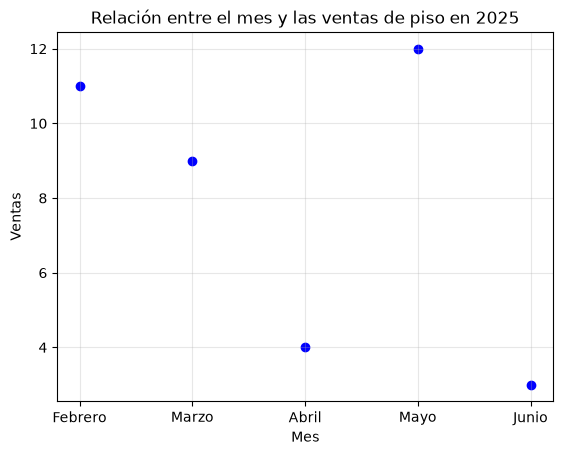

In [40]:
#Importamos la librería para realizar la gráfica

import matplotlib.pyplot as plt

#Creamos la gráfica de dispersión

plt.scatter(
    ventas_mensuales["Mes"],
    ventas_mensuales["Ventas"],
    color="blue"
)

plt.title("Relación entre el mes y las ventas de piso en 2025")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(
    [2, 3, 4, 5, 6],
    ["Febrero", "Marzo", "Abril", "Mayo", "Junio"]
)
plt.grid(alpha=0.3)
plt.show()

In [41]:
#Definimos la variable independiente y la variable dependiente

X = ventas_mensuales[["Mes"]]
y = ventas_mensuales["Ventas"]

#Creamos el modelo de regresión lineal

model = LinearRegression()

#Entrenamos el modelo con nuestros datos

model.fit(X, y)

print("El modelo fue creado correctamente")

El modelo fue creado correctamente


In [42]:
#Mostramos el intercepto y la pendiente del modelo

print("Intercepto:", model.intercept_)
print("Pendiente:", model.coef_[0])

Intercepto: 13.0
Pendiente: -1.3


In [43]:
#Realizamos las predicciones con el modelo

y_pred = model.predict(X)

#Calculamos el coeficiente de determinación

r_cuadrada = model.score(X, y)

print("R cuadrada:", r_cuadrada)

R cuadrada: 0.2529940119760481


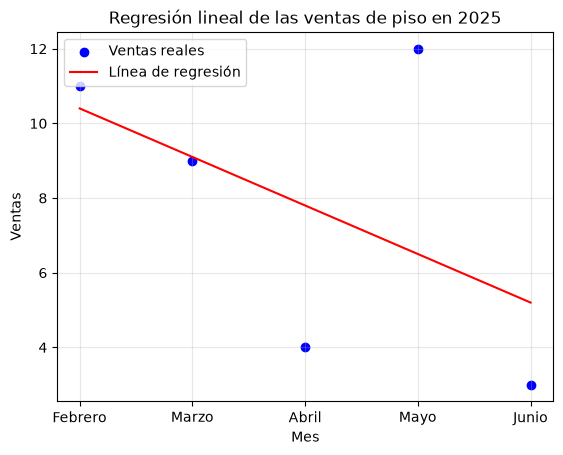

In [44]:
#Graficamos los datos originales

plt.scatter(
    X["Mes"],
    y,
    color="blue",
    label="Ventas reales"
)

#Graficamos la línea de regresión

plt.plot(
    X["Mes"],
    y_pred,
    color="red",
    label="Línea de regresión"
)

plt.title("Regresión lineal de las ventas de piso en 2025")
plt.xlabel("Mes")
plt.ylabel("Ventas")

plt.xticks(
    [2, 3, 4, 5, 6],
    ["Febrero", "Marzo", "Abril", "Mayo", "Junio"]
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [45]:
#Calculamos el coeficiente de correlación

correlacion = ventas_mensuales["Mes"].corr(
    ventas_mensuales["Ventas"]
)

print("Correlación:", correlacion)

Correlación: -0.502985101147189


In [46]:
#Agregamos las ventas estimadas por el modelo

ventas_mensuales["Ventas_Estimadas"] = y_pred

#Calculamos los residuos
#Residuo = valor real - valor estimado

ventas_mensuales["Residuo"] = (
    ventas_mensuales["Ventas"]
    - ventas_mensuales["Ventas_Estimadas"]
)

ventas_mensuales

,Mes,Ventas,Ventas_Estimadas,Residuo
0,2,11,10.4,0.6
1,3,9,9.1,-0.1
2,4,4,7.8,-3.8
3,5,12,6.5,5.5
4,6,3,5.2,-2.2


In [47]:
#Guardamos la base limpia y los resultados en un archivo Excel

with pd.ExcelWriter(
    "resultados_ventas_piso_2025.xlsx",
    engine="openpyxl"
) as writer:
    
    df.to_excel(
        writer,
        sheet_name="Base limpia",
        index=False
    )
    
    df_largo.to_excel(
        writer,
        sheet_name="Formato largo",
        index=False
    )
    
    ventas_mensuales.to_excel(
        writer,
        sheet_name="Regresion",
        index=False
    )

print("Los resultados fueron guardados correctamente")

Los resultados fueron guardados correctamente


In [48]:
#Seleccionamos las variables numéricas para el análisis

datos_correlacion = ventas_mensuales[
    ["Mes", "Ventas"]
]

#Calculamos la matriz de correlación

matriz_correlacion = datos_correlacion.corr()

matriz_correlacion

,Mes,Ventas
Mes,1.000000,-0.502985
Ventas,-0.502985,1.000000


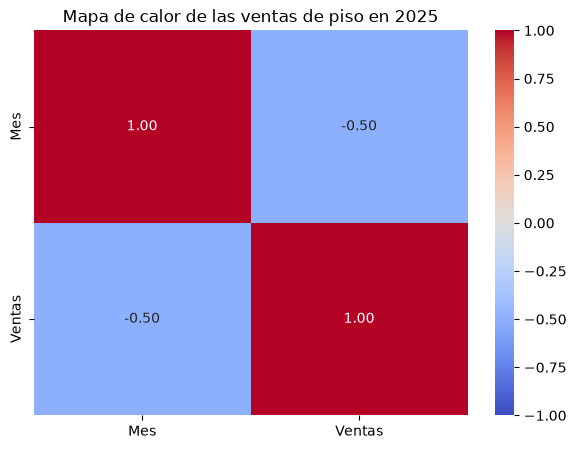

In [49]:
#Importamos la librería para realizar el mapa de calor

import seaborn as sns
import matplotlib.pyplot as plt

#Creamos el mapa de calor

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Mapa de calor de las ventas de piso en 2025")
plt.show()

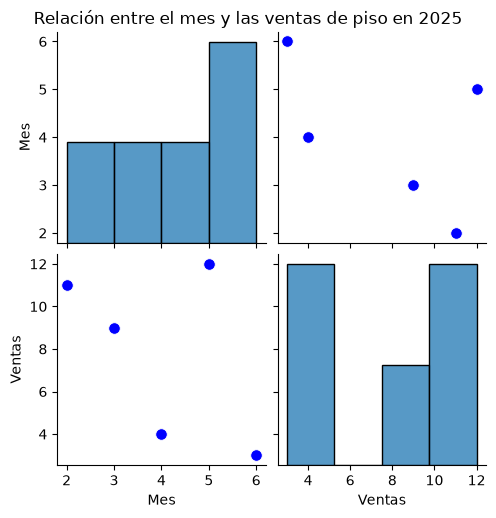

In [50]:
#Creamos una matriz de gráficas para observar
#la relación entre las variables

sns.pairplot(
    datos_correlacion,
    diag_kind="hist",
    plot_kws={
        "color": "blue",
        "s": 70
    }
)

plt.suptitle(
    "Relación entre el mes y las ventas de piso en 2025",
    y=1.02
)

plt.show()

In [51]:
#Cargamos la base sin utilizar ninguna fila como encabezado

archivo = "Analisis GAC Full7agosto 2026( BCS).csv"

df_raw = pd.read_csv(
    archivo,
    header=None,
    encoding="utf-8-sig",
    dtype=str,
    keep_default_na=False
)

print("Dimensiones de la base original:", df_raw.shape)

df_raw.head()

Dimensiones de la base original: (53, 56)


,0,1,2,3,4,5,6,7,8,9,...,46,47,48,49,50,51,52,53,54,55
0,,,,,Balance Socore,,,,,,...,,,,,,,,,,
1,,,,,,,,,,,...,,,,,,,,,,
2,,,,,"Monday, August 24, 2026",,,,,,...,,,,,,,,,,
3,,8/24/2026,,,,,,,,,...,,,,,,,,,,
4,,,,,,,,,,,...,,,,,,,,,,


In [52]:
#Seleccionamos las columnas necesarias para el análisis

df = df_raw.iloc[:, [1, 3, 4]].copy()

#Asignamos nombres claros a las columnas

df.columns = [
    "Modelo",
    "Objetivo",
    "Ventas_Reales"
]

df.head()

,Modelo,Objetivo,Ventas_Reales
0,,,Balance Socore
1,,,
2,,,"Monday, August 24, 2026"
3,8/24/2026,,
4,,,


In [53]:
#Quitamos espacios invisibles y espacios adicionales

df["Modelo"] = (
    df["Modelo"]
    .astype(str)
    .str.replace("\u00a0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.upper()
)

df.head()

,Modelo,Objetivo,Ventas_Reales
0,,,Balance Socore
1,,,
2,,,"Monday, August 24, 2026"
3,8/24/2026,,
4,,,


In [54]:
#Definimos los modelos que vamos a analizar

modelos_analizados = [
    "EMZOOM",
    "AION",
    "EMKOO",
    "GS4",
    "GN8",
    "GS8"
]

#Filtramos únicamente los modelos seleccionados

df = df[
    df["Modelo"].isin(modelos_analizados)
].copy()

df.reset_index(drop=True, inplace=True)

df

,Modelo,Objetivo,Ventas_Reales
0,EMZOOM,22,14
1,AION,2,5
2,EMKOO,7,14
3,GS4,3,5
4,GN8,1,0
5,GS8,9,3


In [55]:
#Seleccionamos las columnas numéricas

columnas_numericas = [
    "Objetivo",
    "Ventas_Reales"
]

#Quitamos espacios y convertimos los datos a números

for columna in columnas_numericas:
    df[columna] = (
        df[columna]
        .astype(str)
        .str.replace("\u00a0", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    )

df

,Modelo,Objetivo,Ventas_Reales
0,EMZOOM,22,14
1,AION,2,5
2,EMKOO,7,14
3,GS4,3,5
4,GN8,1,0
5,GS8,9,3


In [56]:
#Verificamos las dimensiones, los valores nulos
#y los registros duplicados

print("Dimensiones de la base limpia:", df.shape)

print("\nValores nulos:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nTipos de datos:")
print(df.dtypes)

df

Dimensiones de la base limpia: (6, 3)

Valores nulos:
Modelo           0
Objetivo         0
Ventas_Reales    0
dtype: int64

Registros duplicados:
0

Tipos de datos:
Modelo             str
Objetivo         int64
Ventas_Reales    int64
dtype: object


,Modelo,Objetivo,Ventas_Reales
0,EMZOOM,22,14
1,AION,2,5
2,EMKOO,7,14
3,GS4,3,5
4,GN8,1,0
5,GS8,9,3


In [57]:
#Guardamos la base limpia en un archivo Excel

df.to_excel(
    "ventas_bcs_limpia.xlsx",
    index=False
)

print("La base limpia de BCS fue guardada correctamente")

La base limpia de BCS fue guardada correctamente


In [58]:
#Guardamos la base limpia en un archivo Excel

df.to_excel(
    "ventas_bcs_limpia.xlsx",
    index=False
)

print("La base limpia de BCS fue guardada correctamente")

La base limpia de BCS fue guardada correctamente


In [59]:
#Guardamos la base limpia en un archivo Excel

df.to_excel(
    "ventas_bcs_limpia.xlsx",
    index=False
)

print("La base limpia de BCS fue guardada correctamente")

La base limpia de BCS fue guardada correctamente


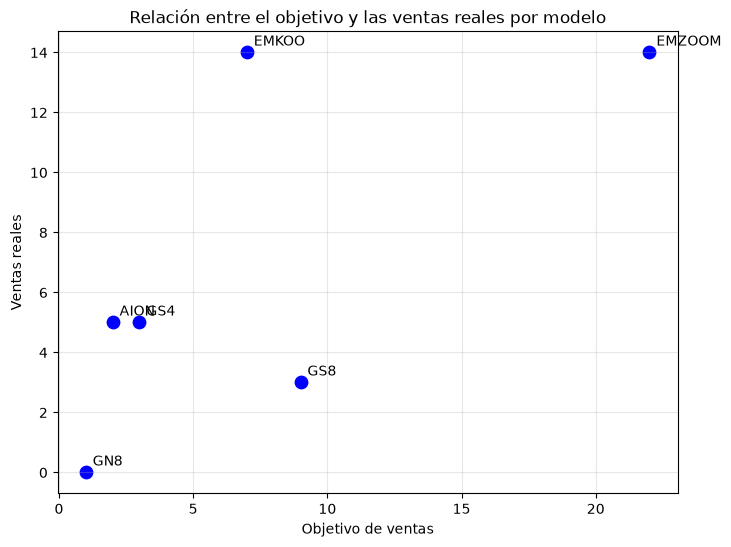

In [60]:
#Creamos la gráfica de dispersión

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Objetivo"],
    df["Ventas_Reales"],
    color="blue",
    s=80
)

#Agregamos el nombre de cada modelo

for i in range(len(df)):
    plt.annotate(
        df.loc[i, "Modelo"],
        (
            df.loc[i, "Objetivo"],
            df.loc[i, "Ventas_Reales"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Relación entre el objetivo y las ventas reales por modelo")
plt.xlabel("Objetivo de ventas")
plt.ylabel("Ventas reales")
plt.grid(alpha=0.3)
plt.show()

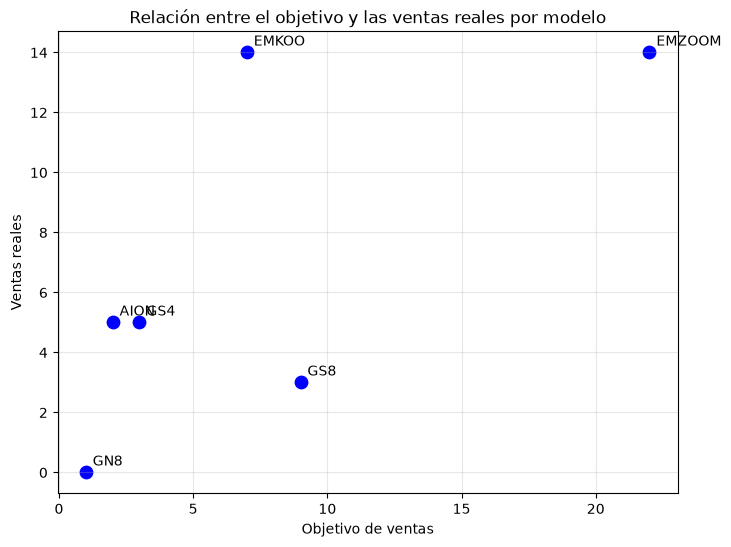

In [61]:
#Creamos la gráfica de dispersión

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Objetivo"],
    df["Ventas_Reales"],
    color="blue",
    s=80
)

#Agregamos el nombre de cada modelo

for i in range(len(df)):
    plt.annotate(
        df.loc[i, "Modelo"],
        (
            df.loc[i, "Objetivo"],
            df.loc[i, "Ventas_Reales"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Relación entre el objetivo y las ventas reales por modelo")
plt.xlabel("Objetivo de ventas")
plt.ylabel("Ventas reales")
plt.grid(alpha=0.3)
plt.show()

In [62]:
#Mostramos el intercepto y la pendiente del modelo

print("Intercepto:", model.intercept_)
print("Pendiente:", model.coef_[0])

Intercepto: 13.0
Pendiente: -1.3


In [64]:
#Realizamos las predicciones con el modelo

y_pred = model.predict(X)

#Calculamos el coeficiente de determinación

r_cuadrada = model.score(X, y)

print("R cuadrada:", r_cuadrada)

R cuadrada: 0.2529940119760481


In [66]:
#Importamos la función de regresión lineal

from sklearn.linear_model import LinearRegression

#Definimos nuevamente las variables de esta base

X = df[["Objetivo"]]
y = df["Ventas_Reales"]

#Creamos y entrenamos nuevamente el modelo

model = LinearRegression()
model.fit(X, y)

#Realizamos las predicciones

y_pred = model.predict(X)

#Calculamos la R cuadrada

r_cuadrada = model.score(X, y)

print("Intercepto:", model.intercept_)
print("Pendiente:", model.coef_[0])
print("R cuadrada:", r_cuadrada)

Intercepto: 3.054585152838429
Pendiente: 0.5152838427947597
R cuadrada: 0.47456385131536927


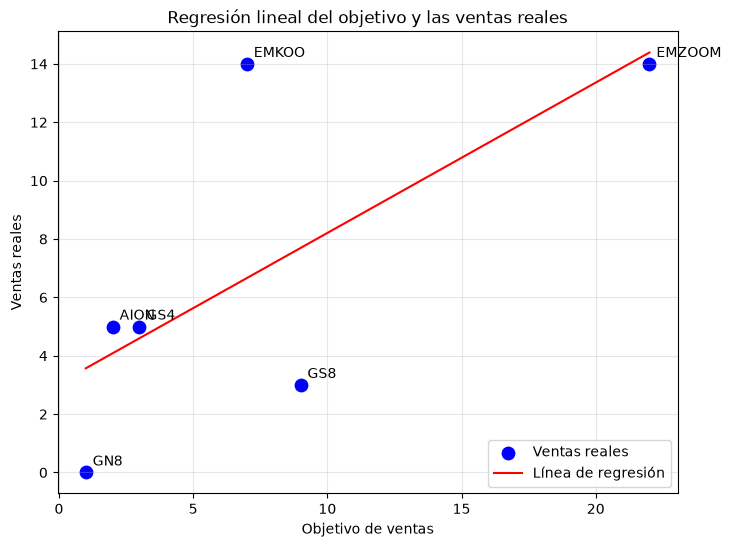

In [67]:
#Ordenamos los datos por objetivo

df_grafica = df.sort_values(
    "Objetivo"
).copy()

#Calculamos las predicciones ordenadas

df_grafica["Ventas_Estimadas"] = model.predict(
    df_grafica[["Objetivo"]]
)

#Creamos la gráfica

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Objetivo"],
    df["Ventas_Reales"],
    color="blue",
    s=80,
    label="Ventas reales"
)

plt.plot(
    df_grafica["Objetivo"],
    df_grafica["Ventas_Estimadas"],
    color="red",
    label="Línea de regresión"
)

#Agregamos el nombre de cada modelo

for i in range(len(df)):
    plt.annotate(
        df.loc[i, "Modelo"],
        (
            df.loc[i, "Objetivo"],
            df.loc[i, "Ventas_Reales"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Regresión lineal del objetivo y las ventas reales")
plt.xlabel("Objetivo de ventas")
plt.ylabel("Ventas reales")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [68]:
#Seleccionamos las variables numéricas

datos_correlacion = df[
    ["Objetivo", "Ventas_Reales"]
]

#Calculamos la matriz de correlación

matriz_correlacion = datos_correlacion.corr()

matriz_correlacion

,Objetivo,Ventas_Reales
Objetivo,1.000000,0.688886
Ventas_Reales,0.688886,1.000000


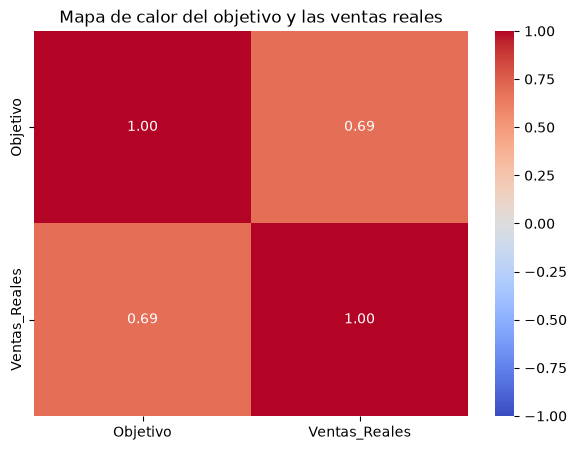

In [69]:
#Creamos el mapa de calor

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Mapa de calor del objetivo y las ventas reales")
plt.show()

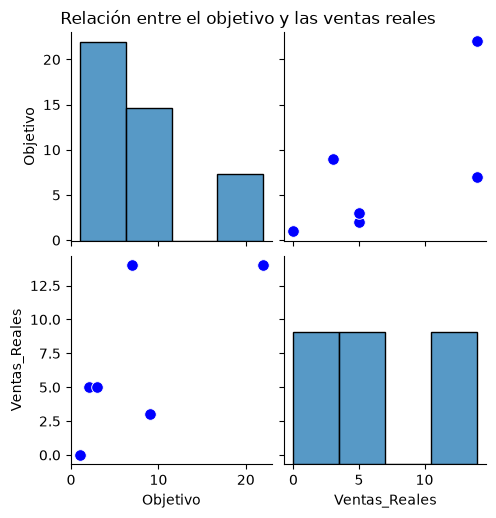

In [70]:
#Creamos la matriz de gráficas

sns.pairplot(
    datos_correlacion,
    diag_kind="hist",
    plot_kws={
        "color": "blue",
        "s": 70
    }
)

plt.suptitle(
    "Relación entre el objetivo y las ventas reales",
    y=1.02
)

plt.show()